## TASK A

Create a prompt that can be used with any LLM to generate the same results as those obtained in the provided Python notebooks:

- “Assignment_8_multiple_regression_methods.ipynb”

The prompt should guide the LLM to reproduce almost similar outputs.

1. Which LLM did you use?  

2. Provide the prompt that you given to LLM

##### Which LLM did you use - GPT 5.3 (OpenAI)

## Prompt

##### Generate code for the following

- Write a complete Python program using pandas, numpy, matplotlib, seaborn, sklearn, statsmodels
- Set reproducibility using np.random.seed(42)
- Read an Excel file named 'data/Assignment_8_regression_multiple_methods.xlsx' with sheets 'train' and 'test'
- Load into train_data and test_data
- Define X = data.drop(columns=['y']) and y = data['y']
- Create X_train, y_train, X_test, y_test for data preparation
- Extract x and y separately for visualization
- Create a scatter plot, use blue dots for train and red cross for test, include title (Train and test data scatterplot), axis labels, legend and grid
- Apply PolynomialFeatures(degree=1) and StandardScaler (fit on train, transform both train & test)
- Generate X_train_poly, X_test_poly
- Convert transformed features to DataFrame using get_feature_names_out()
- Save as augmented_train_data.csv and augmented_train_data.csv

- Create a dictionary with ML algorithms: Linear Regression, SVM (polynomial kernel), Random Forest, Gradient Boosting, KNN, Neural network
- Create a grid of subplots of a row for each algorithm: {ML name} Train, {ML name} Residuals Trains, {ML Name} Test, {ML Name} Residuals Test
- Loop through models: Fit and predict train & test
- Compute R2, RMSE, Durbin-Watson, Jarque-Bera and JB p-value
- Store result in metric_table_train, metric_table_test
- Performance plot by creating subplots (row = model, col = 4) for Train: Actual vs Predicted, Train: Residuals, Test: Actual vs Predicted, Test: Residuals. Use Blue dots for actual and orange dots for predicted
  For each model:

  1. Train: Actual vs Predicted
     - Plot actual values as blue scatter points
     - Sort X values before plotting
     - Plot predicted values as a smooth orange line

  2. Train: Residuals
     - Plot residuals vs predicted values

  3. Test: Actual vs Predicted
     - Plot actual values as blue scatter points
     - Sort X values before plotting
     - Plot predicted values as a smooth orange line

  4. Test: Residuals
     - Plot residuals vs predicted values


- Residual Analysis by creating another subplot grid of row for each ML algorithm having 4 plots: Train - histogram, QQ Plot & Test - histogram, QQ Plot
- Print both the metric tables
- Ensure proper titles and use plt.tight_layout()

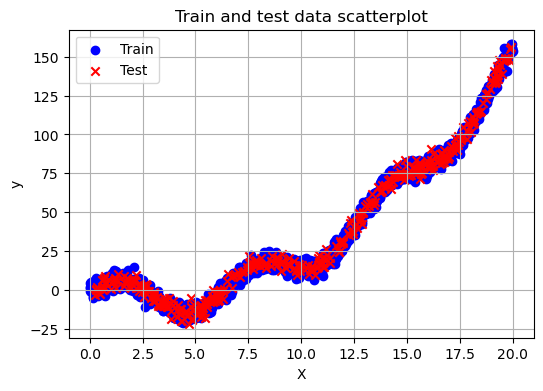

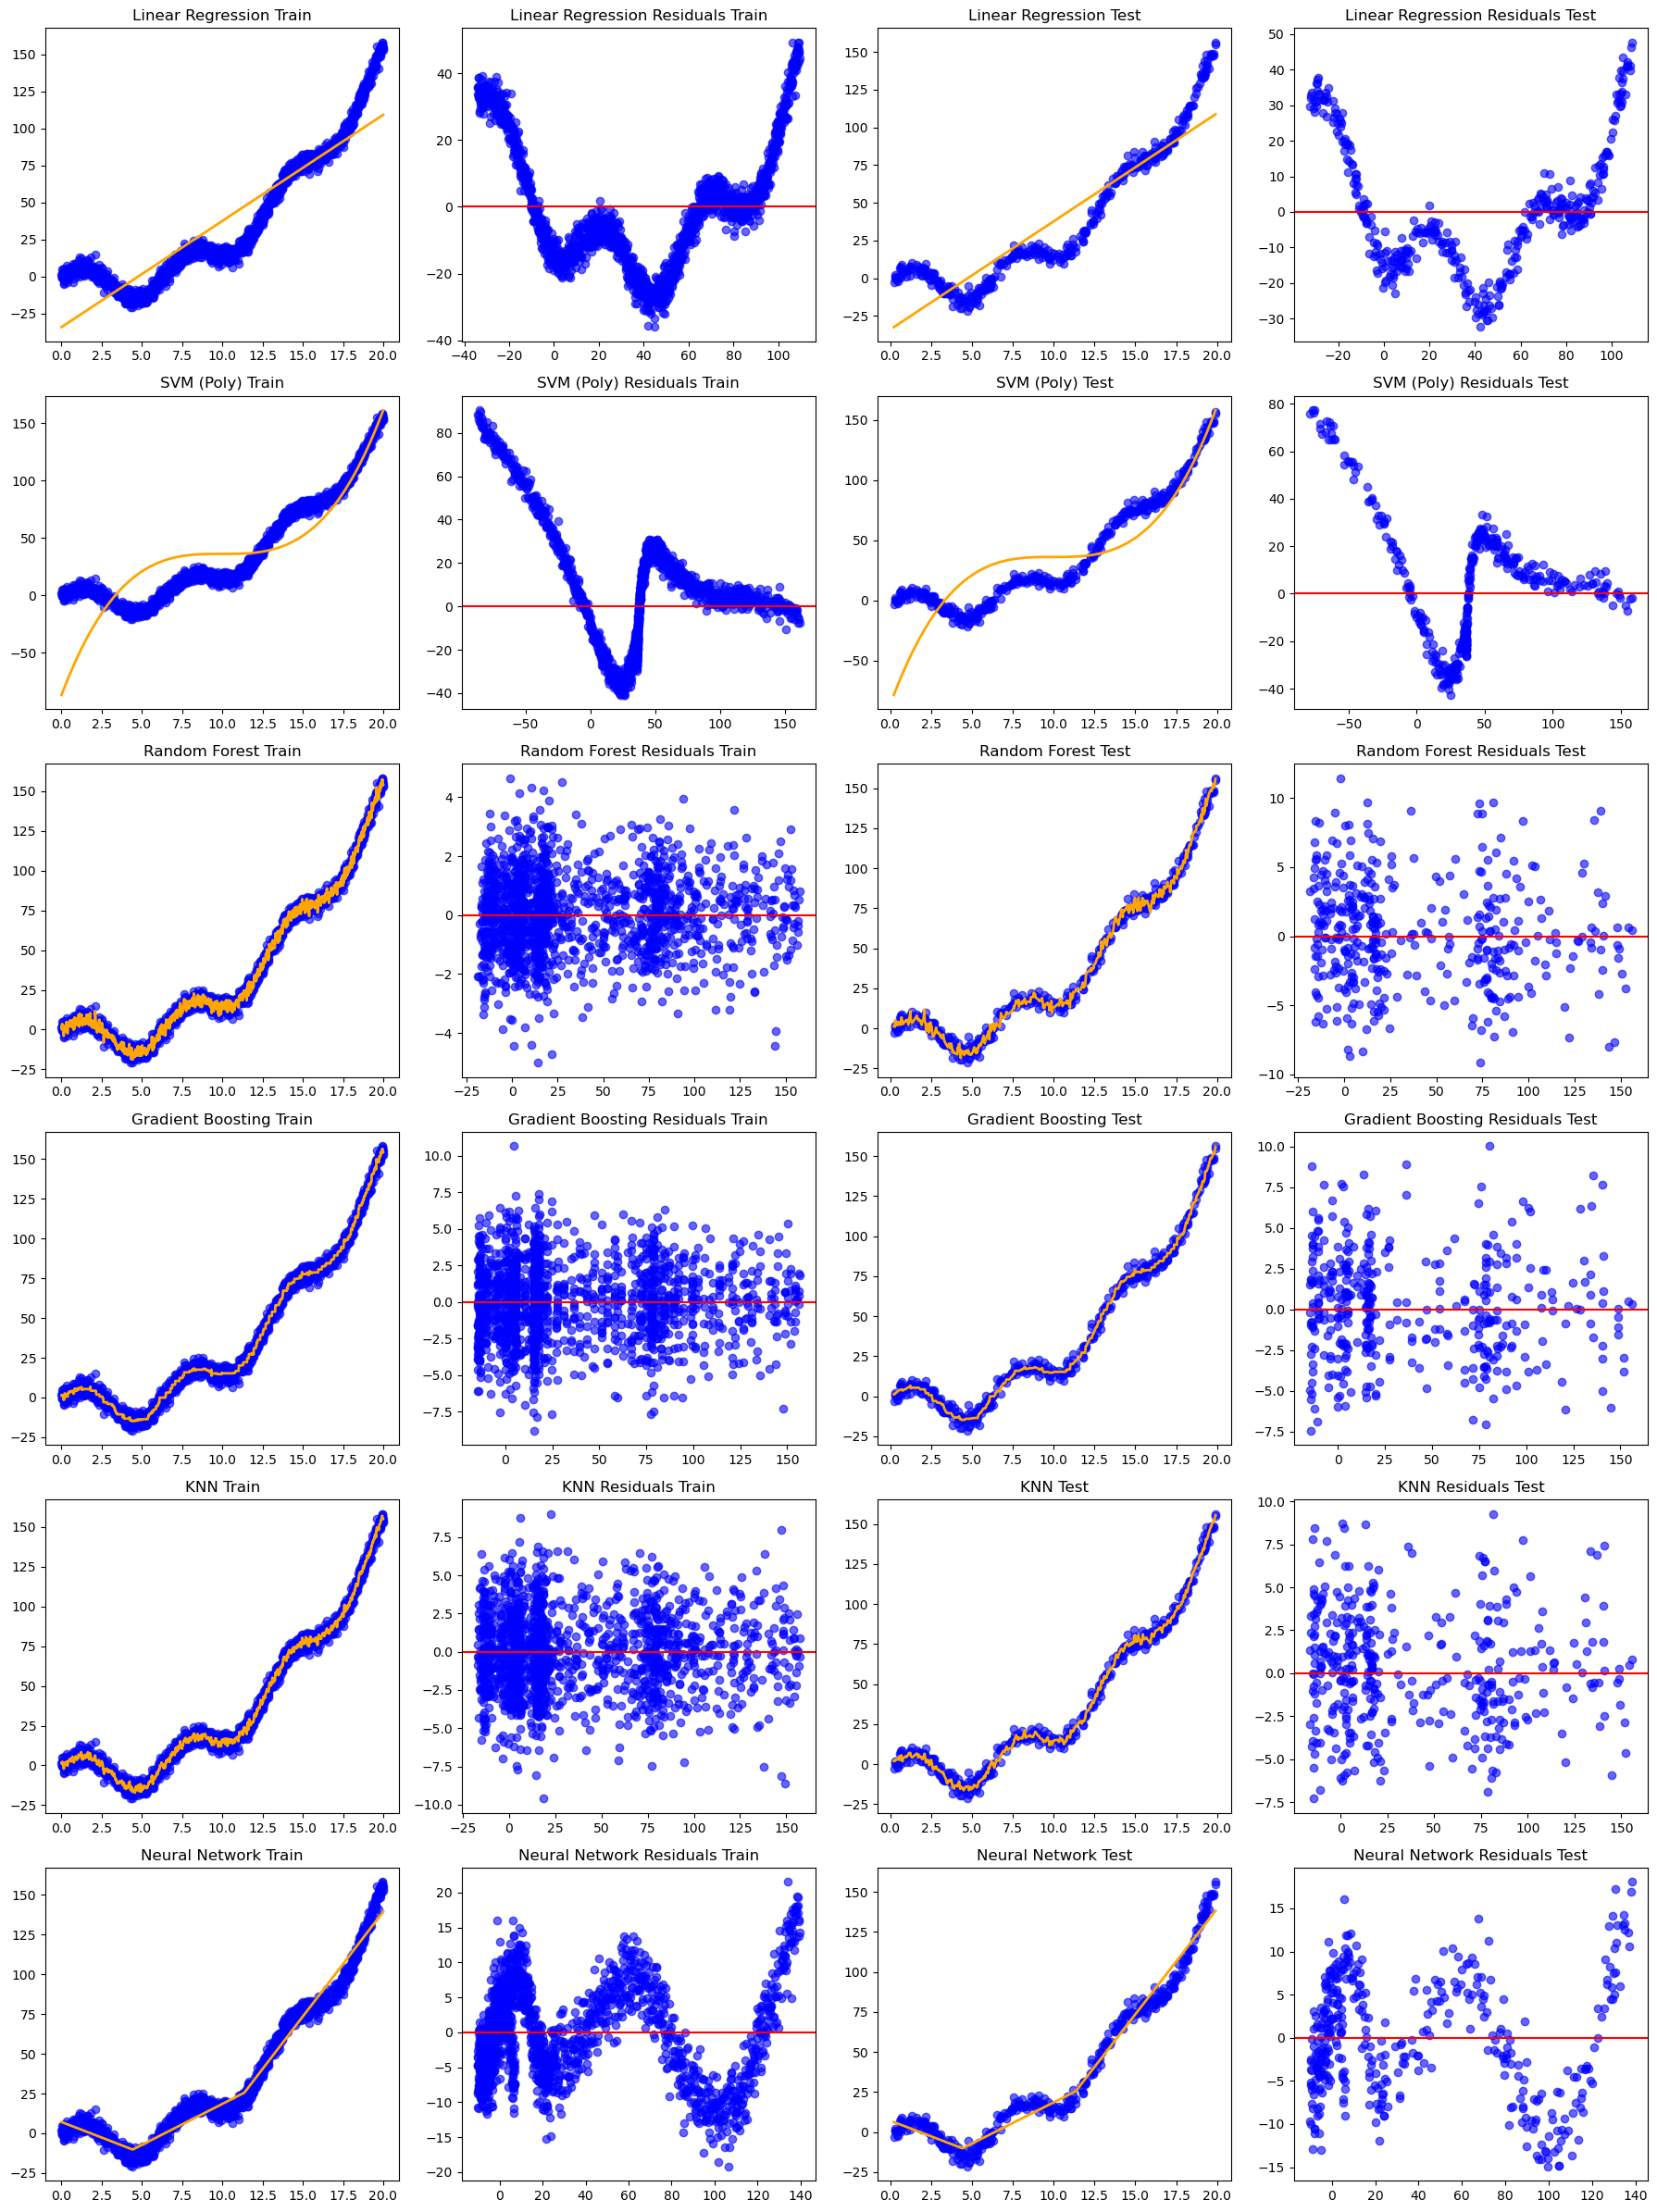

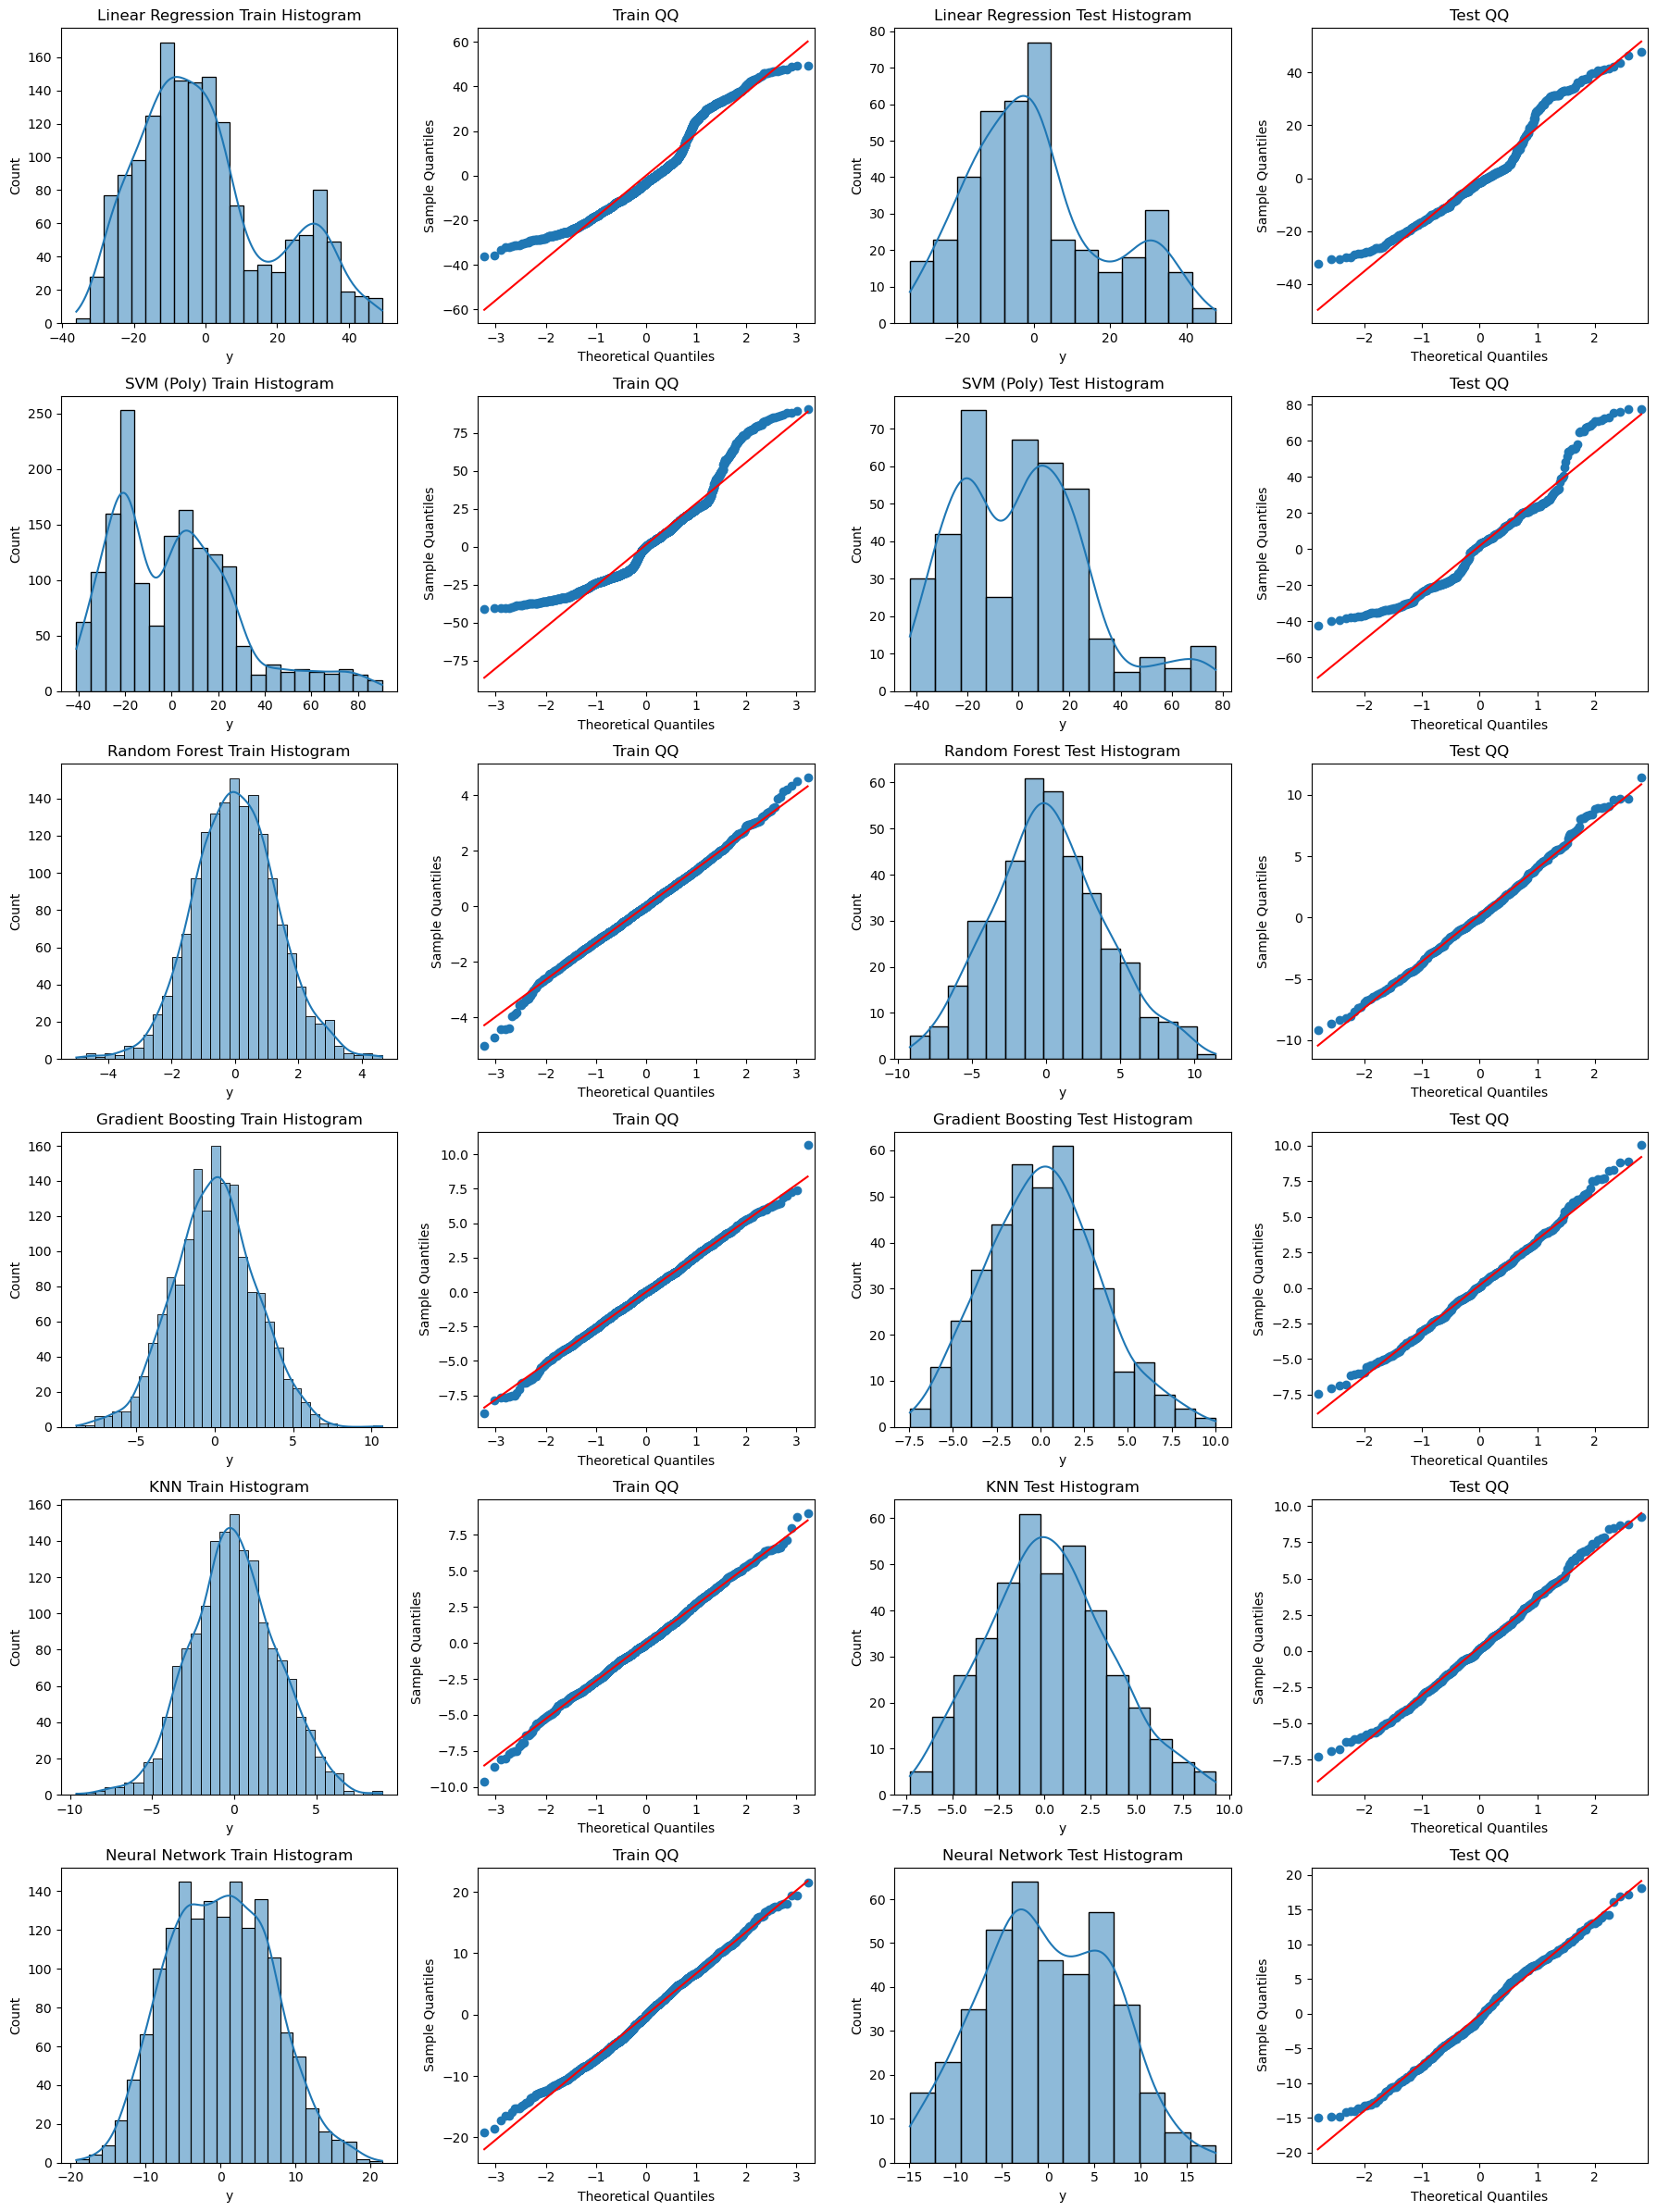


Train Metrics:
               Model        R2       RMSE  Durbin-Watson     JB Stat  \
0  Linear Regression  0.829553  18.656644       2.024608  117.827752   
1         SVM (Poly)  0.638358  27.175561       1.987561  251.590113   
2      Random Forest  0.999131   1.331947       2.053183    9.544990   
3  Gradient Boosting  0.996693   2.598827       2.089983    0.569595   
4                KNN  0.996598   2.635583       2.092051    0.594478   
5     Neural Network  0.977538   6.772759       2.043704   15.845645   

     JB p-value  
0  2.594351e-26  
1  2.332926e-55  
2  8.459249e-03  
3  7.521666e-01  
4  7.428664e-01  
5  3.623780e-04  

Test Metrics:
               Model        R2       RMSE  Durbin-Watson    JB Stat  \
0  Linear Regression  0.850458  18.078457       1.904427  25.441873   
1         SVM (Poly)  0.689803  26.037513       1.990964  35.111435   
2      Random Forest  0.993390   3.800929       2.087827   3.146231   
3  Gradient Boosting  0.995281   3.211352       2.0969

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.graphics.gofplots import qqplot

# -----------------------------
# Reproducibility
# -----------------------------
np.random.seed(42)

# -----------------------------
# Load Data
# -----------------------------
train_data = pd.read_excel(
    "data/Assignment_8_regression_multiple_methods.xlsx", sheet_name="train"
)
test_data = pd.read_excel(
    "data/Assignment_8_regression_multiple_methods.xlsx", sheet_name="test"
)

# -----------------------------
# Prepare Data
# -----------------------------
X_train = train_data.drop(columns=["y"])
y_train = train_data["y"]

X_test = test_data.drop(columns=["y"])
y_test = test_data["y"]

# Extract x (assumes single feature)
x_train = X_train.values.flatten()
x_test = X_test.values.flatten()

# -----------------------------
# Scatter Plot
# -----------------------------
plt.figure(figsize=(6, 4))
plt.scatter(x_train, y_train, color="blue", label="Train")
plt.scatter(x_test, y_test, color="red", marker="x", label="Test")
plt.title("Train and test data scatterplot")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

# -----------------------------
# Feature Engineering
# -----------------------------
poly = PolynomialFeatures(degree=1)
scaler = StandardScaler()

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

# Save augmented data
feature_names = poly.get_feature_names_out()
pd.DataFrame(X_train_scaled, columns=feature_names).to_csv("augmented_train_data.csv", index=False)
pd.DataFrame(X_test_scaled, columns=feature_names).to_csv("augmented_test_data.csv", index=False)

# -----------------------------
# Models
# -----------------------------
models = {
    "Linear Regression": LinearRegression(),
    "SVM (Poly)": SVR(kernel="poly"),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "Neural Network": MLPRegressor(max_iter=1000, random_state=42),
}

metric_table_train = []
metric_table_test = []

# -----------------------------
# PERFORMANCE PLOTS
# -----------------------------
fig_perf, axes_perf = plt.subplots(len(models), 4, figsize=(18, 4 * len(models)))

for i, (name, model) in enumerate(models.items()):

    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    res_train = y_train - y_train_pred
    res_test = y_test - y_test_pred

    # -----------------------------
    # Metrics
    # -----------------------------
    def compute_metrics(y_true, y_pred, residuals):
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        dw = durbin_watson(residuals)
        jb_stat, jb_p, _, _ = jarque_bera(residuals)
        return r2, rmse, dw, jb_stat, jb_p

    metric_table_train.append([name] + list(compute_metrics(y_train, y_train_pred, res_train)))
    metric_table_test.append([name] + list(compute_metrics(y_test, y_test_pred, res_test)))

    # -----------------------------
    # Sort X for smooth curves
    # -----------------------------
    train_idx = np.argsort(x_train)
    test_idx = np.argsort(x_test)

    x_train_sorted = x_train[train_idx]
    y_train_pred_sorted = y_train_pred[train_idx]

    x_test_sorted = x_test[test_idx]
    y_test_pred_sorted = y_test_pred[test_idx]

    # -----------------------------
    # Plotting
    # -----------------------------
    # Train
    axes_perf[i, 0].scatter(x_train, y_train, color="blue", alpha=0.6)
    axes_perf[i, 0].plot(x_train_sorted, y_train_pred_sorted, color="orange", linewidth=2)
    axes_perf[i, 0].set_title(f"{name} Train")

    axes_perf[i, 1].scatter(y_train_pred, res_train, color="blue", alpha=0.6)
    axes_perf[i, 1].axhline(0, color="red")
    axes_perf[i, 1].set_title(f"{name} Residuals Train")

    # Test
    axes_perf[i, 2].scatter(x_test, y_test, color="blue", alpha=0.6)
    axes_perf[i, 2].plot(x_test_sorted, y_test_pred_sorted, color="orange", linewidth=2)
    axes_perf[i, 2].set_title(f"{name} Test")

    axes_perf[i, 3].scatter(y_test_pred, res_test, color="blue", alpha=0.6)
    axes_perf[i, 3].axhline(0, color="red")
    axes_perf[i, 3].set_title(f"{name} Residuals Test")

plt.tight_layout()
plt.show()

# -----------------------------
# RESIDUAL ANALYSIS GRID
# -----------------------------
fig_res, axes_res = plt.subplots(len(models), 4, figsize=(18, 4 * len(models)))

for i, (name, model) in enumerate(models.items()):

    model.fit(X_train_scaled, y_train)

    res_train = y_train - model.predict(X_train_scaled)
    res_test = y_test - model.predict(X_test_scaled)

    # Train Histogram
    sns.histplot(res_train, kde=True, ax=axes_res[i, 0])
    axes_res[i, 0].set_title(f"{name} Train Histogram")

    # Train QQ Plot
    qqplot(res_train, line="s", ax=axes_res[i, 1])
    axes_res[i, 1].set_title("Train QQ")

    # Test Histogram
    sns.histplot(res_test, kde=True, ax=axes_res[i, 2])
    axes_res[i, 2].set_title(f"{name} Test Histogram")

    # Test QQ Plot
    qqplot(res_test, line="s", ax=axes_res[i, 3])
    axes_res[i, 3].set_title("Test QQ")

plt.tight_layout()
plt.show()

# -----------------------------
# Metrics Tables
# -----------------------------
columns = ["Model", "R2", "RMSE", "Durbin-Watson", "JB Stat", "JB p-value"]

metric_table_train = pd.DataFrame(metric_table_train, columns=columns)
metric_table_test = pd.DataFrame(metric_table_test, columns=columns)

print("\nTrain Metrics:")
print(metric_table_train)

print("\nTest Metrics:")
print(metric_table_test)